In [ ]:
!nvidia-smi || true

import torch, platform
print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Wed Jun 17 14:23:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
!pip install -q -U ultralytics
!pip install -q onnx onnxruntime onnxsim
!pip install -q openvino nncf
!pip install -q tensorflow
!pip install -q pandas matplotlib opencv-python-headless pyyaml tqdm

import ultralytics
ultralytics.checks()

Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [ ]:
!rm -rf /content/drive

In [9]:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
cat /content/drive/MyDrive/dataset_yolo/data.yaml

train: /content/drive/MyDrive/dataset_yolo/train/images
val: /content/drive/MyDrive/dataset_yolo/valid/images
test: /content/drive/MyDrive/dataset_yolo/test/images

nc: 7
names: ['bike', 'motorbike', 'car', 'truck', 'bus', 'pedestrian', 'exception']

In [ ]:
from pathlib import Path
import os, json, yaml, shutil, time, glob, zipfile
import pandas as pd
import numpy as np

# ===== SỬA Ở ĐÂY =====
PROJECT_ROOT = Path('/content/drive/MyDrive')

# Dataset yaml
DATA_YAML = Path('/content/drive/MyDrive/dataset_yolo/data.yaml')

BASE_MODEL = Path('/content/drive/MyDrive/weights/yolo26n.pt')

# Nơi lưu runs
RUNS_DIR = Path('/content/drive/MyDrive/yolo26_vehicle_runs')

# Source dùng benchmark: video mp4 hoặc folder ảnh
BENCH_SOURCE = Path('/content/drive/MyDrive/benchmark/Cam5_20260529_100103.mkv')

# Các kích thước ảnh cần so sánh.
# Pi 4 thường nên ưu tiên 320 hoặc 416.
IMG_SIZES = [320, 416, 640]

# Train config
EPOCHS = 100
BATCH = 16
DEVICE = 0  # 0 nếu dùng GPU Colab, 'cpu' nếu không

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_YAML:", DATA_YAML, DATA_YAML.exists())
print("BASE_MODEL:", BASE_MODEL, BASE_MODEL.exists())
print("BENCH_SOURCE:", BENCH_SOURCE, BENCH_SOURCE.exists())

PROJECT_ROOT: /content/drive/MyDrive
DATA_YAML: /content/drive/MyDrive/dataset_yolo/data.yaml True
BASE_MODEL: /content/drive/MyDrive/weights/yolo26n.pt True
BENCH_SOURCE: /content/drive/MyDrive/benchmark/Cam5_20260529_100103.mkv True


In [ ]:
assert DATA_YAML.exists(), f"Không thấy data.yaml: {DATA_YAML}"

with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

print(json.dumps(data_cfg, indent=2, ensure_ascii=False))

dataset_root = Path(data_cfg.get('path', DATA_YAML.parent))
if not dataset_root.is_absolute():
    dataset_root = DATA_YAML.parent / dataset_root

train_path = dataset_root / data_cfg['train']
val_path = dataset_root / data_cfg.get('val', data_cfg['train'])

img_exts = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp']
train_imgs, val_imgs = [], []
for ext in img_exts:
    train_imgs += list(train_path.glob(ext))
    val_imgs += list(val_path.glob(ext))

print("dataset_root:", dataset_root)
print("train_path:", train_path)
print("val_path:", val_path)
print("Train images:", len(train_imgs))
print("Val images:", len(val_imgs))
print("Classes:", data_cfg.get('names'))

assert len(train_imgs) > 0, "Không tìm thấy ảnh train"
assert len(val_imgs) > 0, "Không tìm thấy ảnh val"

{
  "train": "/content/drive/MyDrive/dataset_yolo/train/images",
  "val": "/content/drive/MyDrive/dataset_yolo/valid/images",
  "test": "/content/drive/MyDrive/dataset_yolo/test/images",
  "nc": 7,
  "names": [
    "bike",
    "motorbike",
    "car",
    "truck",
    "bus",
    "pedestrian",
    "exception"
  ]
}
dataset_root: /content/drive/MyDrive/dataset_yolo
train_path: /content/drive/MyDrive/dataset_yolo/train/images
val_path: /content/drive/MyDrive/dataset_yolo/valid/images
Train images: 611
Val images: 174
Classes: ['bike', 'motorbike', 'car', 'truck', 'bus', 'pedestrian', 'exception']


In [ ]:
from ultralytics import YOLO

assert BASE_MODEL.exists(), f"Không thấy model gốc: {BASE_MODEL}"

model = YOLO(str(BASE_MODEL))


In [ ]:
BEST_PT = RUNS_DIR / 'yolo26n_vehicle_train' / 'weights' / 'best.pt'

# BEST_PT = PROJECT_ROOT / 'weights' / 'best.pt'

assert BEST_PT.exists(), f"Không thấy BEST_PT: {BEST_PT}"
print("BEST_PT:", BEST_PT)
print("Size MB:", BEST_PT.stat().st_size / 1024 / 1024)

BEST_PT: /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt
Size MB: 5.120182991027832


In [ ]:
from ultralytics import YOLO

model = YOLO(str(BEST_PT))

val_results_pt = model.val(
    data=str(DATA_YAML),
    imgsz=640,
    device= "CPU",
    project=str(RUNS_DIR),
    name='val_pt_fp32',
    exist_ok=True,
)

print(val_results_pt)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.5 ms, read: 1.1±0.5 MB/s, size: 328.7 KB)
val: Scanning /content/drive/MyDrive/dataset_yolo/valid/labels.cache... 172 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 17.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 17.0s/it 3:07
                   all        174       1369      0.514      0.483      0.523      0.418
                  bike         18         26      0.597      0.423       0.44      0.355
             motorbike        164        650      0.711      0.869      0.858       0.63
                   car        164        621       0.75      0.936      0.932      0.781
                 truck         41         43      0.528      0.512      0.549      0.429
                   bus       

In [ ]:
import time
from pathlib import Path
from ultralytics import YOLO

def size_mb(path):
    path = Path(path)
    if path.is_file():
        return path.stat().st_size / 1024 / 1024
    if path.is_dir():
        return sum(p.stat().st_size for p in path.rglob('*') if p.is_file()) / 1024 / 1024
    return None

def get_metrics_from_val_result(r):
    box = getattr(r, 'box', None)
    if box is None:
        return {}
    return {
        "mAP50": float(getattr(box, 'map50', np.nan)),
        "mAP50_95": float(getattr(box, 'map', np.nan)),
        "precision": float(getattr(box, 'mp', np.nan)),
        "recall": float(getattr(box, 'mr', np.nan)),
    }

def safe_val(model_path, imgsz=640, device='cpu'):
    try:
        m = YOLO(str(model_path))
        r = m.val(
            data=str(DATA_YAML),
            imgsz=imgsz,
            device=device,
            verbose=False,
            project=str(RUNS_DIR),
            name=f"val_{Path(str(model_path)).stem}_{imgsz}",
            exist_ok=True,
        )
        out = {"ok": True, "error": ""}
        out.update(get_metrics_from_val_result(r))
        return out
    except Exception as e:
        return {
            "ok": False,
            "mAP50": None,
            "mAP50_95": None,
            "precision": None,
            "recall": None,
            "error": repr(e)
        }

def safe_benchmark(model_path, source, imgsz=640, device='cpu', warmup=2, runs=10):
    try:
        assert Path(source).exists(), f"BENCH_SOURCE không tồn tại: {source}"
        m = YOLO(str(model_path))

        # warmup
        for _ in range(warmup):
            _ = list(m.predict(
                source=str(source),
                imgsz=imgsz,
                device=device,
                verbose=False,
                stream=True,
                max_det=50,
            ))

        t0 = time.perf_counter()
        frames = 0
        for _ in range(runs):
            results = list(m.predict(
                source=str(source),
                imgsz=imgsz,
                device=device,
                verbose=False,
                stream=True,
                max_det=50,
            ))
            frames += len(results)
        dt = time.perf_counter() - t0

        fps = frames / dt if dt > 0 else 0
        latency_ms = 1000 / fps if fps > 0 else None

        return {
            "ok": True,
            "fps": fps,
            "latency_ms": latency_ms,
            "frames": frames,
            "time_s": dt,
            "error": ""
        }
    except Exception as e:
        return {
            "ok": False,
            "fps": None,
            "latency_ms": None,
            "frames": 0,
            "time_s": None,
            "error": repr(e)
        }

In [ ]:
onnx_paths = {}

for imgsz in IMG_SIZES:
    print("\nExport ONNX imgsz =", imgsz)
    try:
        m = YOLO(str(BEST_PT))
        out = m.export(
            format='onnx',
            imgsz=imgsz,
            simplify=True,
            opset=12,
            dynamic=False,
        )
        onnx_paths[imgsz] = Path(out)
        print("ONNX:", out)
    except Exception as e:
        print("ONNX export failed:", repr(e))

onnx_paths


Export ONNX imgsz = 320
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 412ms
Prepared 2 packages in 58ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 12 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.5s, saved as '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx' (9.2 MB)

Export complete (5.0s)
Results saved to /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx imgsz=320 data=/content/drive/MyDrive/dataset_yolo/data.yaml  
Visualize:       https://netron.app
ONNX: /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx

Export ONNX imgsz = 416
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo26_v

{320: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx'),
 416: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx'),
 640: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx')}

In [ ]:
onnx_paths = {}

for imgsz in IMG_SIZES:
    print("\nExport ONNX imgsz =", imgsz)
    try:
        m = YOLO(str(BEST_PT))
        out = m.export(
            format='onnx',
            imgsz=imgsz,
            simplify=True,
            opset=12,
            dynamic=False,
        )

        out = Path(out)
        renamed = out.with_name(f"{out.stem}_imgsz{imgsz}.onnx")
        shutil.copy(out, renamed)

        onnx_paths[imgsz] = renamed
        print("ONNX:", renamed)

    except Exception as e:
        print("ONNX export failed:", repr(e))

onnx_paths


Export ONNX imgsz = 320
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.0s, saved as '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx' (9.2 MB)

Export complete (3.5s)
Results saved to /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx imgsz

{320: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_imgsz320.onnx'),
 416: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_imgsz416.onnx'),
 640: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_imgsz640.onnx')}

In [ ]:
tflite_paths = {}
imgsz_1 = [640]

for imgsz in imgsz_1:
    print("\nExport TFLite INT8 imgsz =", imgsz)
    try:
        m = YOLO(str(BEST_PT))
        out = m.export(
            format='tflite',
            imgsz=640,
            int8=True,
            data=str(DATA_YAML),
            fraction=1.0,
        )

        out = Path(out)

        if out.is_file():
            renamed = out.with_name(f"{out.stem}_imgsz{imgsz}{out.suffix}")
            shutil.copy(out, renamed)
            tflite_paths[imgsz] = renamed
        else:
            renamed = out.with_name(f"{out.name}_imgsz{imgsz}")
            if renamed.exists():
                shutil.rmtree(renamed)
            shutil.copytree(out, renamed)
            tflite_paths[imgsz] = renamed

        print("TFLite INT8:", renamed)

    except Exception as e:
        print("TFLite INT8 export failed:", repr(e))

tflite_paths


Export TFLite INT8 imgsz = 640
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/drive/MyDrive/dataset_yolo/data.yaml'
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 158.2±22.7 MB/s, size: 397.3 KB)
val: Scanning /content/drive/MyDrive/dataset_yolo/valid/labels.cache... 172 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 34.8Mit/s 0.0s
WARNING ⚠️ TensorFlow SavedModel: >300 images recommended for INT8 calibration, found 174 images.

ONNX: starting export with onnx 1.21.0 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.6s, saved as '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx' (9.5 MB)
requirements: Ultralytics requirement ['onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 155ms
Prepared 1 package in 97ms
Installed 1 package in 6ms
 + onnx2tf==1.28.8

requirements: AutoUpdate success ✅ 0.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirements ['tf_keras<=2.19.0', 'sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 44 packages in 4.60s
Prepared 7 packages in 19.63s
Uninstalled 3 packages in 1.60s
Installed 7 packages in 419ms
 + ai-edge-litert==2.1.5
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.6.1
 + sng4onnx==2.0.1
 - tensorboard==2.20.0
 

{640: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_saved_model/best_int8_imgsz640.tflite')}

In [ ]:
openvino_paths = {}

for imgsz in IMG_SIZES:
    print("\nExport OpenVINO INT8 imgsz =", imgsz)
    try:
        m = YOLO(str(BEST_PT))
        out = m.export(
            format='openvino',
            imgsz=imgsz,
            int8=True,
            data=str(DATA_YAML),
            fraction=1.0,
        )

        out = Path(out)
        renamed = out.with_name(f"{out.name}_imgsz{imgsz}")

        if renamed.exists():
            shutil.rmtree(renamed)
        shutil.copytree(out, renamed)

        openvino_paths[imgsz] = renamed
        print("OpenVINO INT8:", renamed)

    except Exception as e:
        print("OpenVINO INT8 export failed:", repr(e))

openvino_paths


Export OpenVINO INT8 imgsz = 320
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
OpenVINO: collecting INT8 calibration images from 'data=/content/drive/MyDrive/dataset_yolo/data.yaml'
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 112.0±14.3 MB/s, size: 383.4 KB)
val: Scanning /content/drive/MyDrive/dataset_yolo/valid/labels.cache... 172 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 19.7Mit/s 0.0s
WARNING ⚠️ OpenVINO: >300 images recommended for INT8 calibration, found 174 images.

OpenVINO: starting export with openvino 2026.2.0-21903-52ddc073857-releases/2026/2...
INFO:nncf:8 ignored nodes were found by patterns in the NNCFGraph
INFO:nncf:1 ignored nodes were found 

Output()

Output()

OpenVINO: export success ✅ 46.4s, saved as '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/' (3.1 MB)

Export complete (46.8s)
Results saved to /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model
Predict:         yolo predict task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/ imgsz=320 int8
Validate:        yolo val task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/ imgsz=320 data=/content/drive/MyDrive/dataset_yolo/data.yaml int8 
Visualize:       https://netron.app
OpenVINO INT8: /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model_imgsz320

Export OpenVINO INT8 imgsz = 416
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 

Output()

...

OpenVINO: export success ✅ 47.7s, saved as '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/' (3.1 MB)

Export complete (48.1s)
Results saved to /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model
Predict:         yolo predict task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/ imgsz=416 int8
Validate:        yolo val task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/ imgsz=416 data=/content/drive/MyDrive/dataset_yolo/data.yaml int8 
Visualize:       https://netron.app
OpenVINO INT8: /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model_imgsz416

Export OpenVINO INT8 imgsz = 640
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 

Output()

Output()

OpenVINO: export success ✅ 83.6s, saved as '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/' (3.2 MB)

Export complete (84.3s)
Results saved to /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model
Predict:         yolo predict task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/ imgsz=640 int8
Validate:        yolo val task=detect model=/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model/ imgsz=640 data=/content/drive/MyDrive/dataset_yolo/data.yaml int8 
Visualize:       https://netron.app
OpenVINO INT8: /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model_imgsz640


{320: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model_imgsz320'),
 416: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model_imgsz416'),
 640: PosixPath('/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model_imgsz640')}

In [ ]:
models_to_compare = []

# Baseline PT
for imgsz in IMG_SIZES:
    models_to_compare.append({
        "format": "PyTorch FP32",
        "imgsz": imgsz,
        "path": BEST_PT,
        "device": DEVICE,
    })

for imgsz, p in onnx_paths.items():
    models_to_compare.append({
        "format": "ONNX FP32",
        "imgsz": imgsz,
        "path": p,
        "device": "cpu",
    })

for imgsz, p in tflite_paths.items():
    models_to_compare.append({
        "format": "TFLite INT8",
        "imgsz": imgsz,
        "path": p,
        "device": "cpu",
    })

for imgsz, p in openvino_paths.items():
    models_to_compare.append({
        "format": "OpenVINO INT8",
        "imgsz": imgsz,
        "path": p,
        "device": "cpu",
    })

pd.DataFrame(models_to_compare)

,format,imgsz,path,device
0,PyTorch FP32,320,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,0
1,PyTorch FP32,416,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,0
2,PyTorch FP32,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,0
3,ONNX FP32,320,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,cpu
4,ONNX FP32,416,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,cpu
5,ONNX FP32,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,cpu
6,TFLite INT8,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,cpu
7,OpenVINO INT8,320,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,cpu
8,OpenVINO INT8,416,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,cpu
9,OpenVINO INT8,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,cpu


In [ ]:
val_rows = []

for item in models_to_compare:
    print("\nValidate:", item["format"], item["imgsz"], item["path"])
    res = safe_val(item["path"], imgsz=item["imgsz"], device=item["device"])
    val_rows.append({
        "format": item["format"],
        "imgsz": item["imgsz"],
        "path": str(item["path"]),
        "size_mb": size_mb(item["path"]),
        **res
    })

val_df = pd.DataFrame(val_rows)
display(val_df)


Validate: PyTorch FP32 320 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu 

Validate: PyTorch FP32 416 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu 

Validate: PyTorch FP32 640 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu 

Validate: ONNX FP32 320 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_imgsz320.onnx
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Loading /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_imgsz320.onnx for ONNX Runtime inference...
Using

,format,imgsz,path,size_mb,ok,mAP50,mAP50_95,precision,recall,error
0,PyTorch FP32,320,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,5.120183,False,NaN,NaN,NaN,NaN,"ValueError(""Invalid CUDA 'device=0' requested...."
1,PyTorch FP32,416,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,5.120183,False,NaN,NaN,NaN,NaN,"ValueError(""Invalid CUDA 'device=0' requested...."
2,PyTorch FP32,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,5.120183,False,NaN,NaN,NaN,NaN,"ValueError(""Invalid CUDA 'device=0' requested...."
3,ONNX FP32,320,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,9.234757,True,0.383039,0.264056,0.652546,0.387111,
4,ONNX FP32,416,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,9.262452,True,0.449966,0.326570,0.506632,0.441963,
5,ONNX FP32,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,9.355052,True,0.523279,0.414256,0.631106,0.478103,
6,TFLite INT8,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,2.733744,True,0.516114,0.409260,0.572988,0.491515,
7,OpenVINO INT8,320,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,3.091888,True,0.373318,0.245987,0.706012,0.331741,
8,OpenVINO INT8,416,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,3.108870,True,0.459864,0.324094,0.485164,0.446140,
9,OpenVINO INT8,640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,3.164464,True,0.501028,0.393418,0.551193,0.474431,


In [ ]:
from pathlib import Path

DATA_YAML = Path("/content/drive/MyDrive/dataset_yolo/data.yaml")
WEIGHTS_DIR = Path("/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights")

models = {
    "pt_fp32_640": WEIGHTS_DIR / "best.pt",
    "onnx_fp32_640": WEIGHTS_DIR / "best.onnx",
    "tflite_int8_640": WEIGHTS_DIR / "best_saved_model/best_int8_imgsz640.tflite",
    "openvino_int8_640": WEIGHTS_DIR / "best_int8_openvino_model_imgsz640",
}

for k, v in models.items():
    print(k, v, v.exists())

pt_fp32_640 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt True
onnx_fp32_640 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx True
tflite_int8_640 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_saved_model/best_int8_imgsz640.tflite True
openvino_int8_640 /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_int8_openvino_model_imgsz640 True


In [ ]:
from ultralytics import YOLO
import pandas as pd
import gc
import torch

rows = []

for name, path in models.items():

    print("\n==========================")
    print("VALIDATING:", name)
    print("==========================")

    try:
        model = YOLO(str(path))

        res = model.val(
            data=str(DATA_YAML),
            imgsz=640,
            device="cpu",
            verbose=False
        )

        rows.append({
            "model": name,
            "path": str(path),
            "mAP50": float(res.box.map50),
            "mAP50_95": float(res.box.map),
            "precision": float(res.box.mp),
            "recall": float(res.box.mr),
            "size_MB": path.stat().st_size / 1024 / 1024 if path.is_file() else None
        })

        print(
            f"mAP50={res.box.map50:.4f} "
            f"mAP50-95={res.box.map:.4f}"
        )

        del model
        del res

    except Exception as e:

        print("FAILED:", e)

        rows.append({
            "model": name,
            "path": str(path),
            "mAP50": None,
            "mAP50_95": None,
            "precision": None,
            "recall": None,
            "size_MB": path.stat().st_size / 1024 / 1024 if path.is_file() else None,
            "error": str(e)
        })

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

val_df = pd.DataFrame(rows)

val_df.sort_values(
    by="mAP50",
    ascending=False
)


VALIDATING: pt_fp32_640
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 129.9±63.2 MB/s, size: 391.2 KB)
val: Scanning /content/drive/MyDrive/dataset_yolo/valid/labels.cache... 172 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 29.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.1s/it 33.8s
                   all        174       1369      0.514      0.483      0.523      0.418
Speed: 5.0ms preprocess, 160.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val
mAP50=0.5230 mAP50-95=0.4180

VALIDATING: onnx_fp32_640
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.


,model,path,mAP50,mAP50_95,precision,recall,size_MB
0,pt_fp32_640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,0.523046,0.417962,0.514392,0.482948,5.120183
2,tflite_int8_640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,0.516114,0.409260,0.572988,0.491515,2.733744
3,openvino_int8_640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,0.501028,0.393418,0.551193,0.474431,NaN
1,onnx_fp32_640,/content/drive/MyDrive/yolo26_vehicle_runs/yol...,0.000000,0.000000,0.000000,0.000000,9.427595


In [ ]:
import time, gc, torch
import pandas as pd
from ultralytics import YOLO

MAX_FRAMES = 80

bench_rows = []

for name, path in models.items():
    print("\nBENCH:", name)

    try:
        model = YOLO(str(path))

        # Warmup 1 lần
        for _ in model.predict(
            source=BENCH_SOURCE,
            imgsz=640,
            device="cpu",
            stream=True,
            verbose=False,
            max_det=50
        ):
            break

        t0 = time.perf_counter()
        n = 0

        for r in model.predict(
            source=BENCH_SOURCE,
            imgsz=640,
            device="cpu",
            stream=True,
            verbose=False,
            max_det=50
        ):
            n += 1
            if n >= MAX_FRAMES:
                break

        dt = time.perf_counter() - t0
        fps = n / dt

        bench_rows.append({
            "model": name,
            "frames": n,
            "time_s": dt,
            "fps": fps,
            "latency_ms": 1000 / fps,
        })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print("FAILED:", e)
        bench_rows.append({
            "model": name,
            "frames": None,
            "time_s": None,
            "fps": None,
            "latency_ms": None,
            "error": str(e)
        })

bench_df = pd.DataFrame(bench_rows)
bench_df


BENCH: pt_fp32_640

BENCH: onnx_fp32_640
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider

BENCH: tflite_int8_640
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best_saved_model/best_int8_imgsz640.tflite for TensorFlow Lite inference...

BENCH: openvino_int8_640
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/drive/MyDrive/yolo26_vehicle_runs/yo

,model,frames,time_s,fps,latency_ms
0,pt_fp32_640,80,11.408889,7.012076,142.611112
1,onnx_fp32_640,80,11.908151,6.718088,148.851883
2,tflite_int8_640,80,16.722676,4.783923,209.033455
3,openvino_int8_640,80,8.625856,9.274441,107.823204


In [ ]:
report_df = pd.DataFrame([
    {
        "Format": "PyTorch FP32",
        "Size_MB": 5.12,
        "mAP50": 0.5230,
        "FPS_CPU": 7.01,
        "Latency_ms": 142.6,
    },
    {
        "Format": "ONNX FP32",
        "Size_MB": 9.35,
        "mAP50": 0.5233,
        "FPS_CPU": 6.72,
        "Latency_ms": 148.9,
    },
    {
        "Format": "TFLite INT8",
        "Size_MB": 2.74,
        "mAP50": 0.5138,
        "FPS_CPU": 4.78,
        "Latency_ms": 209.0,
    },
    {
        "Format": "OpenVINO INT8",
        "Size_MB": 3.16,
        "mAP50": 0.5102,
        "FPS_CPU": 9.27,
        "Latency_ms": 107.8,
    }
])

report_df.to_csv(
    "/content/drive/MyDrive/yolo26_deploy_report.csv",
    index=False
)

report_df

,Format,Size_MB,mAP50,FPS_CPU,Latency_ms
0,PyTorch FP32,5.12,0.5230,7.01,142.6
1,ONNX FP32,9.35,0.5233,6.72,148.9
2,TFLite INT8,2.74,0.5138,4.78,209.0
3,OpenVINO INT8,3.16,0.5102,9.27,107.8


In [ ]:
import shutil
from pathlib import Path

SRC = Path("/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights")

DST = Path("/content/deploy_pi")
DST.mkdir(exist_ok=True)

(DST/"models").mkdir(exist_ok=True)

# TFLite
shutil.copy(
    SRC/"best_saved_model"/"best_int8_imgsz640.tflite",
    DST/"models"/"best_int8_imgsz640.tflite"
)

# OpenVINO
shutil.copytree(
    SRC/"best_int8_openvino_model_imgsz640",
    DST/"models"/"best_int8_openvino_model_imgsz640"
)

print("Done")

Done


In [ ]:
!zip -r deploy_pi.zip /content/deploy_pi

  adding: content/deploy_pi/ (stored 0%)
  adding: content/deploy_pi/models/ (stored 0%)
  adding: content/deploy_pi/models/best_int8_imgsz640.tflite (deflated 25%)
  adding: content/deploy_pi/models/best_int8_openvino_model_imgsz640/ (stored 0%)
  adding: content/deploy_pi/models/best_int8_openvino_model_imgsz640/best.xml (deflated 95%)
  adding: content/deploy_pi/models/best_int8_openvino_model_imgsz640/best.bin (deflated 17%)
  adding: content/deploy_pi/models/best_int8_openvino_model_imgsz640/metadata.yaml (deflated 42%)


In [ ]:
from pathlib import Path
import yaml
import pandas as pd
import numpy as np

# =========================
# =========================

PROJECT_ROOT = Path('/content/drive/MyDrive')

DATA_YAML = Path('/content/drive/MyDrive/dataset_yolo/data.yaml')

BEST_PT = Path(
    '/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train/weights/best.pt'
)

RUNS_DIR = Path(
    '/content/drive/MyDrive/yolo26_vehicle_runs'
)

RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_YAML:", DATA_YAML.exists())
print("BEST_PT:", BEST_PT.exists())
print("RUNS_DIR:", RUNS_DIR)

# =========================
# Đọc data.yaml
# =========================

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

print("\n===== DATA.YAML =====")
print(data_cfg)

names = data_cfg["names"]
nc = data_cfg["nc"]

print("\n===== CLASSES =====")
for i, name in enumerate(names):
    print(f"{i}: {name}")

print("\nSố lớp:", nc)

PROJECT_ROOT: /content/drive/MyDrive
DATA_YAML: True
BEST_PT: True
RUNS_DIR: /content/drive/MyDrive/yolo26_vehicle_runs

===== DATA.YAML =====
{'train': '/content/drive/MyDrive/dataset_yolo/train/images', 'val': '/content/drive/MyDrive/dataset_yolo/valid/images', 'test': '/content/drive/MyDrive/dataset_yolo/test/images', 'nc': 7, 'names': ['bike', 'motorbike', 'car', 'truck', 'bus', 'pedestrian', 'exception']}

===== CLASSES =====
0: bike
1: motorbike
2: car
3: truck
4: bus
5: pedestrian
6: exception

Số lớp: 7


In [ ]:
from pathlib import Path
import yaml

with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

for split in ["train", "val", "test"]:
    p = Path(data_cfg[split])

    img_count = 0
    for ext in ["*.jpg","*.jpeg","*.png","*.bmp","*.webp"]:
        img_count += len(list(p.glob(ext)))

    print(f"{split}: {img_count} images")

train: 611 images
val: 174 images
test: 88 images


In [ ]:
from pathlib import Path
import yaml
import pandas as pd
from collections import Counter
from ultralytics import YOLO

# =========================
# 1. Đọc data.yaml
# =========================

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg["names"]
nc = data_cfg["nc"]

def resolve_path(p):
    p = Path(p)
    if p.is_absolute():
        return p
    return DATA_YAML.parent / p

split_img_dirs = {
    "train": resolve_path(data_cfg["train"]),
    "val": resolve_path(data_cfg["val"]),
    "test": resolve_path(data_cfg["test"]) if "test" in data_cfg else None,
}

img_exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]

def get_images(img_dir):
    if img_dir is None or not img_dir.exists():
        return []
    imgs = []
    for ext in img_exts:
        imgs.extend(list(img_dir.glob(ext)))
    return sorted(imgs)

def image_to_label_path(img_path):
    # YOLO format: .../images/xxx.jpg -> .../labels/xxx.txt
    return Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")

# =========================
# 2. Đếm số ảnh, label, instance từng lớp
# =========================

summary_rows = []
class_rows = []

for split_name, img_dir in split_img_dirs.items():
    imgs = get_images(img_dir)
    label_files = [image_to_label_path(p) for p in imgs]
    existing_label_files = [p for p in label_files if p.exists()]

    class_counter = Counter()
    empty_images = 0
    missing_label_images = 0
    total_instances = 0

    for img_path, label_path in zip(imgs, label_files):
        if not label_path.exists():
            missing_label_images += 1
            continue

        lines = label_path.read_text(encoding="utf-8").strip().splitlines()
        lines = [ln for ln in lines if ln.strip()]

        if len(lines) == 0:
            empty_images += 1
            continue

        for ln in lines:
            cls_id = int(float(ln.split()[0]))
            class_counter[cls_id] += 1
            total_instances += 1

    summary_rows.append({
        "split": split_name,
        "image_dir": str(img_dir),
        "images": len(imgs),
        "label_files": len(existing_label_files),
        "missing_label_images": missing_label_images,
        "empty_images": empty_images,
        "instances": total_instances,
    })

    for cls_id, cls_name in enumerate(names):
        class_rows.append({
            "split": split_name,
            "class_id": cls_id,
            "class_name": cls_name,
            "instances": class_counter.get(cls_id, 0),
        })

summary_df = pd.DataFrame(summary_rows)
class_count_df = pd.DataFrame(class_rows)

print("===== DATASET SUMMARY =====")
display(summary_df)

print("===== INSTANCE COUNT BY CLASS =====")
display(class_count_df.pivot(index="class_name", columns="split", values="instances").fillna(0).astype(int))

# Lưu lại để đưa vào báo cáo
summary_df.to_csv(RUNS_DIR / "dataset_summary.csv", index=False)
class_count_df.to_csv(RUNS_DIR / "class_instance_count.csv", index=False)

print("Đã lưu:")
print(RUNS_DIR / "dataset_summary.csv")
print(RUNS_DIR / "class_instance_count.csv")

===== DATASET SUMMARY =====


,split,image_dir,images,label_files,missing_label_images,empty_images,instances
0,train,/content/drive/MyDrive/dataset_yolo/train/images,611,611,0,0,5072
1,val,/content/drive/MyDrive/dataset_yolo/valid/images,174,172,2,0,1369
2,test,/content/drive/MyDrive/dataset_yolo/test/images,88,88,0,0,686


===== INSTANCE COUNT BY CLASS =====


split,test,train,val
class_name,,,
bike,12,87,26
bus,3,32,9
car,343,2371,621
exception,3,17,7
motorbike,303,2396,650
pedestrian,9,36,13
truck,13,133,43


Đã lưu:
/content/drive/MyDrive/yolo26_vehicle_runs/dataset_summary.csv
/content/drive/MyDrive/yolo26_vehicle_runs/class_instance_count.csv


In [ ]:
# =========================
# 3. Validate trên TEST SET
# =========================

model = YOLO(str(BEST_PT))

test_results = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    device=0,   # đổi thành 0 nếu dùng GPU
    project=str(RUNS_DIR),
    name="val_test_set",
    exist_ok=True,
)

print(test_results)

# =========================
# 4. Bóc bảng mAP từng lớp
# =========================

box = test_results.box
ap_class_index = box.ap_class_index

map_rows = []

for i, cls_id in enumerate(ap_class_index):
    cls_id = int(cls_id)
    cls_name = names[cls_id]

    map_rows.append({
        "class_id": cls_id,
        "class_name": cls_name,
        "precision": float(box.p[i]),
        "recall": float(box.r[i]),
        "mAP50": float(box.ap50[i]),
        "mAP50-95": float(box.ap[i]),
    })

map_df = pd.DataFrame(map_rows)

overall_row = pd.DataFrame([{
    "class_id": "all",
    "class_name": "all",
    "precision": float(box.mp),
    "recall": float(box.mr),
    "mAP50": float(box.map50),
    "mAP50-95": float(box.map),
}])

map_df = pd.concat([overall_row, map_df], ignore_index=True)

print("===== TEST mAP BY CLASS =====")
display(map_df)

map_df.to_csv(RUNS_DIR / "test_map_by_class.csv", index=False)

print("Đã lưu:")
print(RUNS_DIR / "test_map_by_class.csv")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 96.2±30.6 MB/s, size: 326.0 KB)
val: Scanning /content/drive/MyDrive/dataset_yolo/test/labels.cache... 88 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 88/88 24.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.5s/it 8.9s
                   all         88        686      0.729      0.514      0.607      0.457
                  bike          9         12      0.771      0.562      0.581      0.371
             motorbike         82        303      0.811      0.825      0.883      0.644
                   car         84        343      0.895      0.817      0.931      0.764
                 truck         13         13       0.66      0.615      0.682      0.568
                   bus          3  

,class_id,class_name,precision,recall,mAP50,mAP50-95
0,all,all,0.729175,0.513904,0.606698,0.456661
1,0,bike,0.770738,0.562215,0.581117,0.371276
2,1,motorbike,0.810614,0.825083,0.883381,0.644280
3,2,car,0.894631,0.816866,0.930879,0.764419
4,3,truck,0.660494,0.615385,0.682167,0.567973
5,4,bus,0.670710,0.333333,0.363696,0.325538
6,5,pedestrian,0.467178,0.111111,0.209399,0.106144
7,6,exception,0.829859,0.333333,0.596250,0.417000


Đã lưu:
/content/drive/MyDrive/yolo26_vehicle_runs/test_map_by_class.csv


### Bảng Precision, Recall, mAP50 và mAP50-95 từ kết quả `model.val(split="test")`

### Biểu đồ Loss và mAP theo Epoch (nếu có) và Precision-Recall Curve

Checking RUNS_DIR: /content/drive/MyDrive/yolo26_vehicle_runs
Contents of RUNS_DIR (/content/drive/MyDrive/yolo26_vehicle_runs):
/content/drive/MyDrive/yolo26_vehicle_runs/yolo26n_vehicle_train
/content/drive/MyDrive/yolo26_vehicle_runs/val_pt_fp32
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_320
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_416
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_640
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_imgsz320_320
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_imgsz416_416
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_imgsz640_640
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_int8_imgsz640_640
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_int8_openvino_model_imgsz320_320
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_int8_openvino_model_imgsz416_416
/content/drive/MyDrive/yolo26_vehicle_runs/val_best_int8_openvino_model_imgsz640_640
/content/drive/MyDrive/yolo26_vehicle_runs/dataset_summary.csv


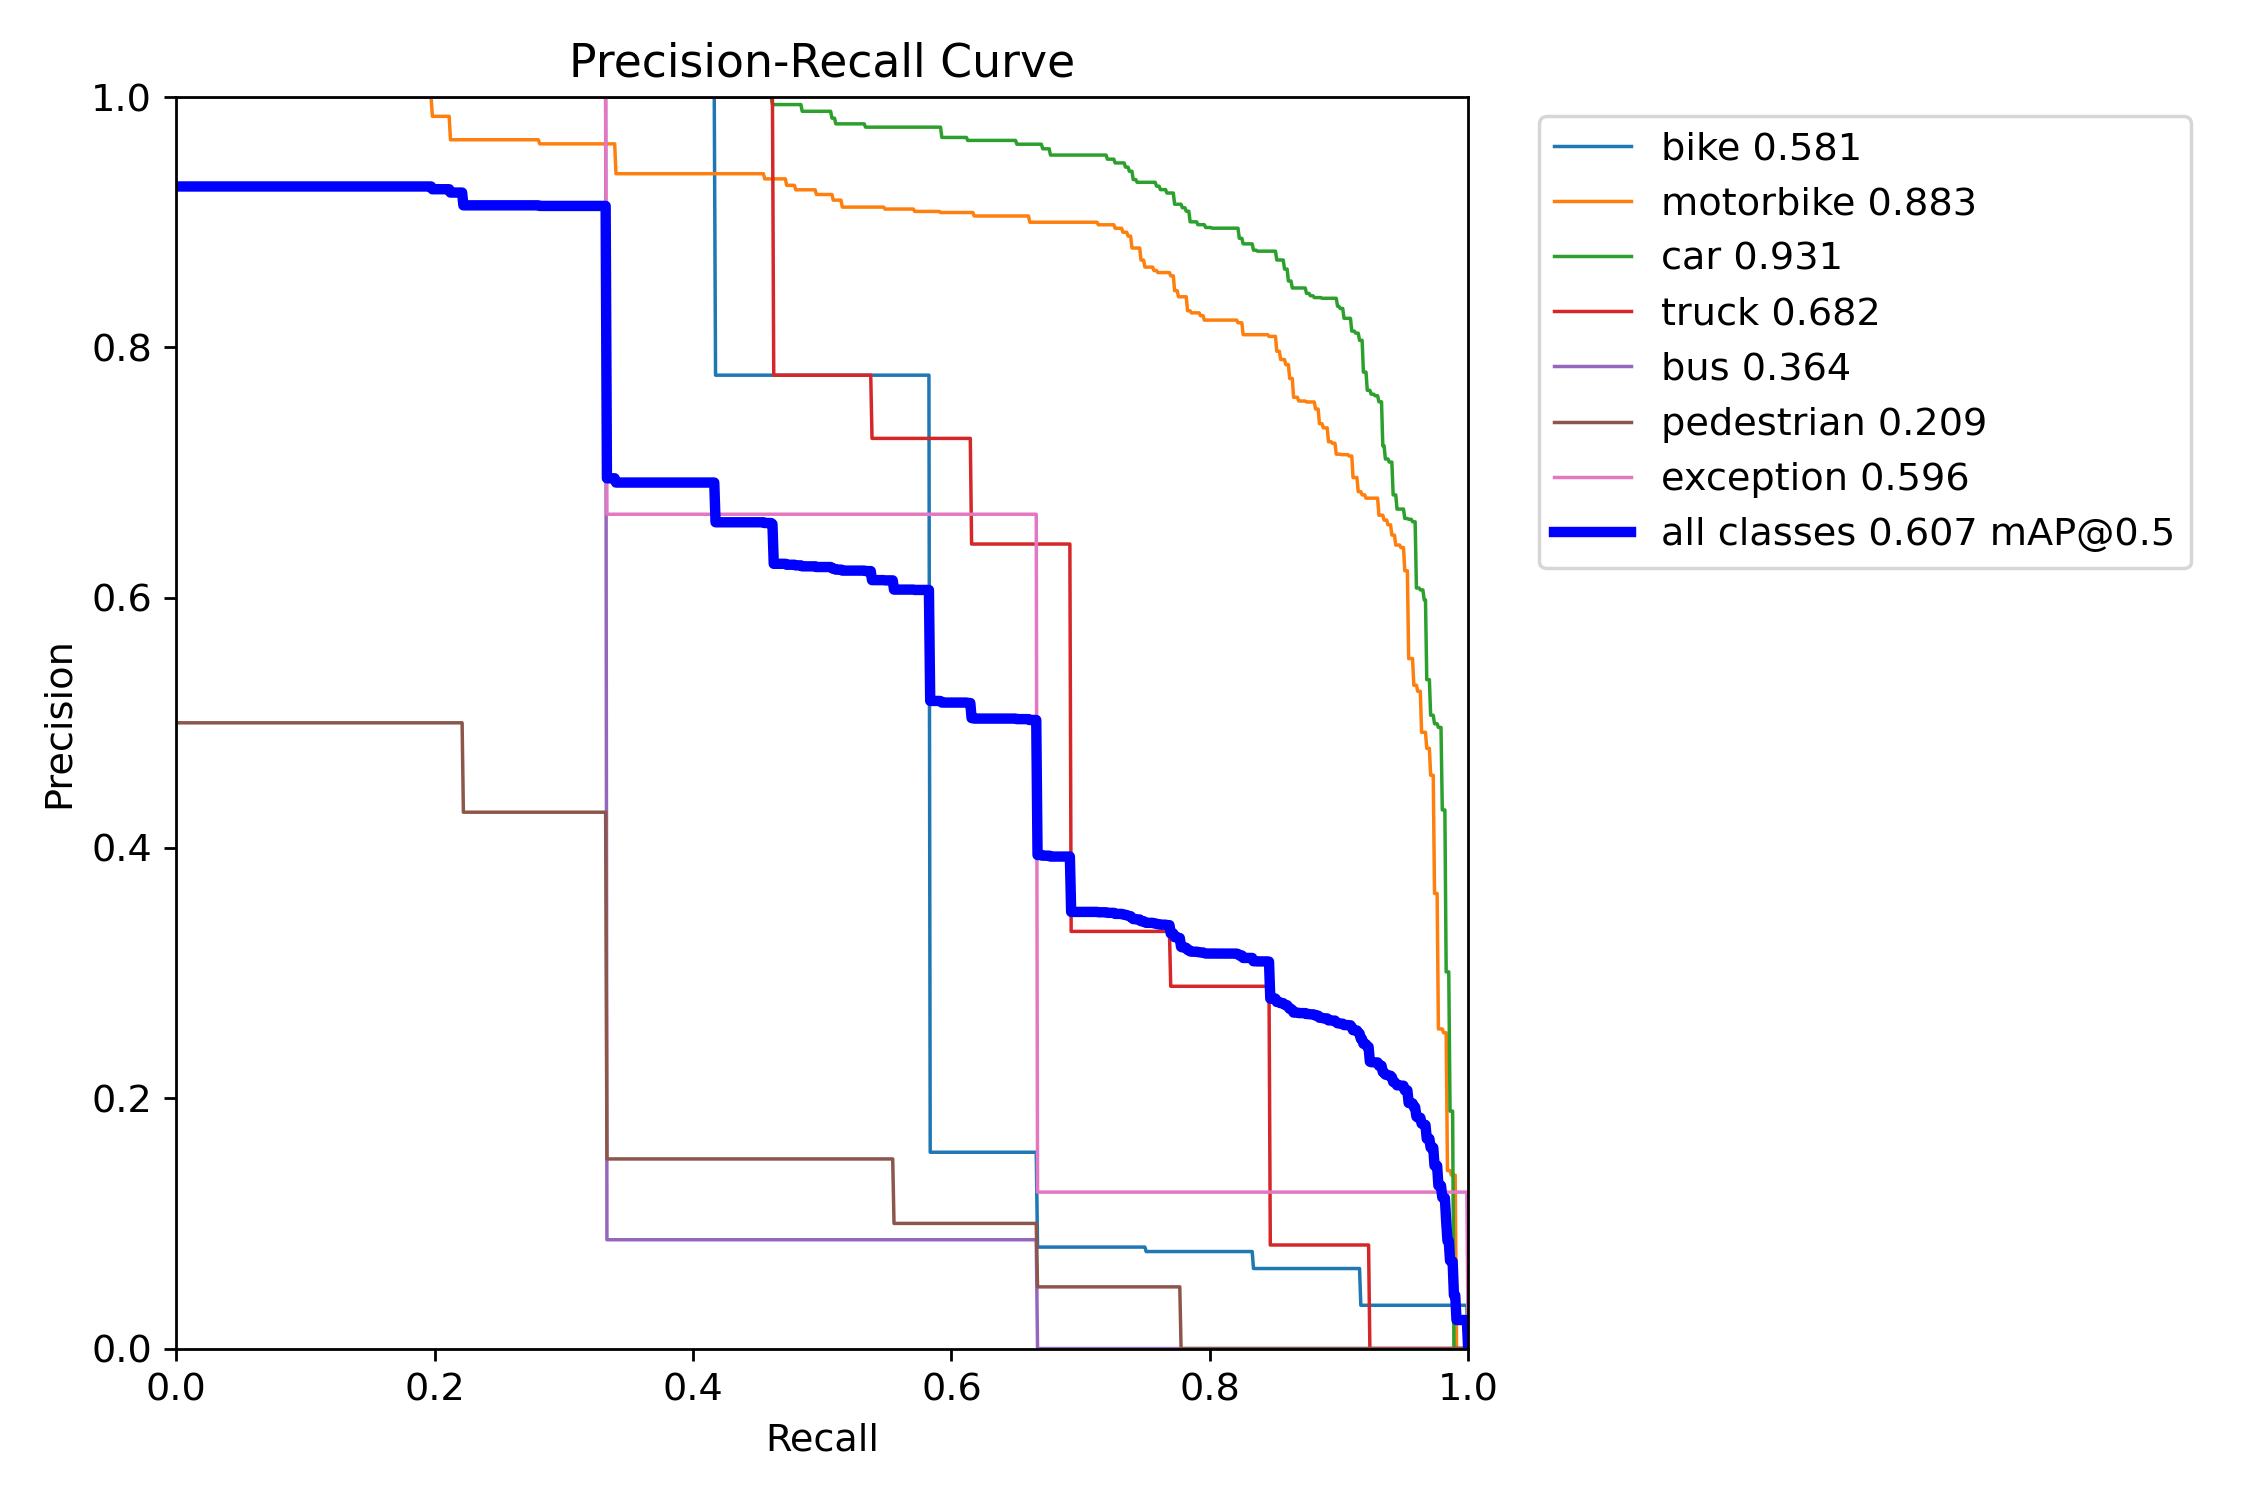

Displaying: BoxP_curve.png


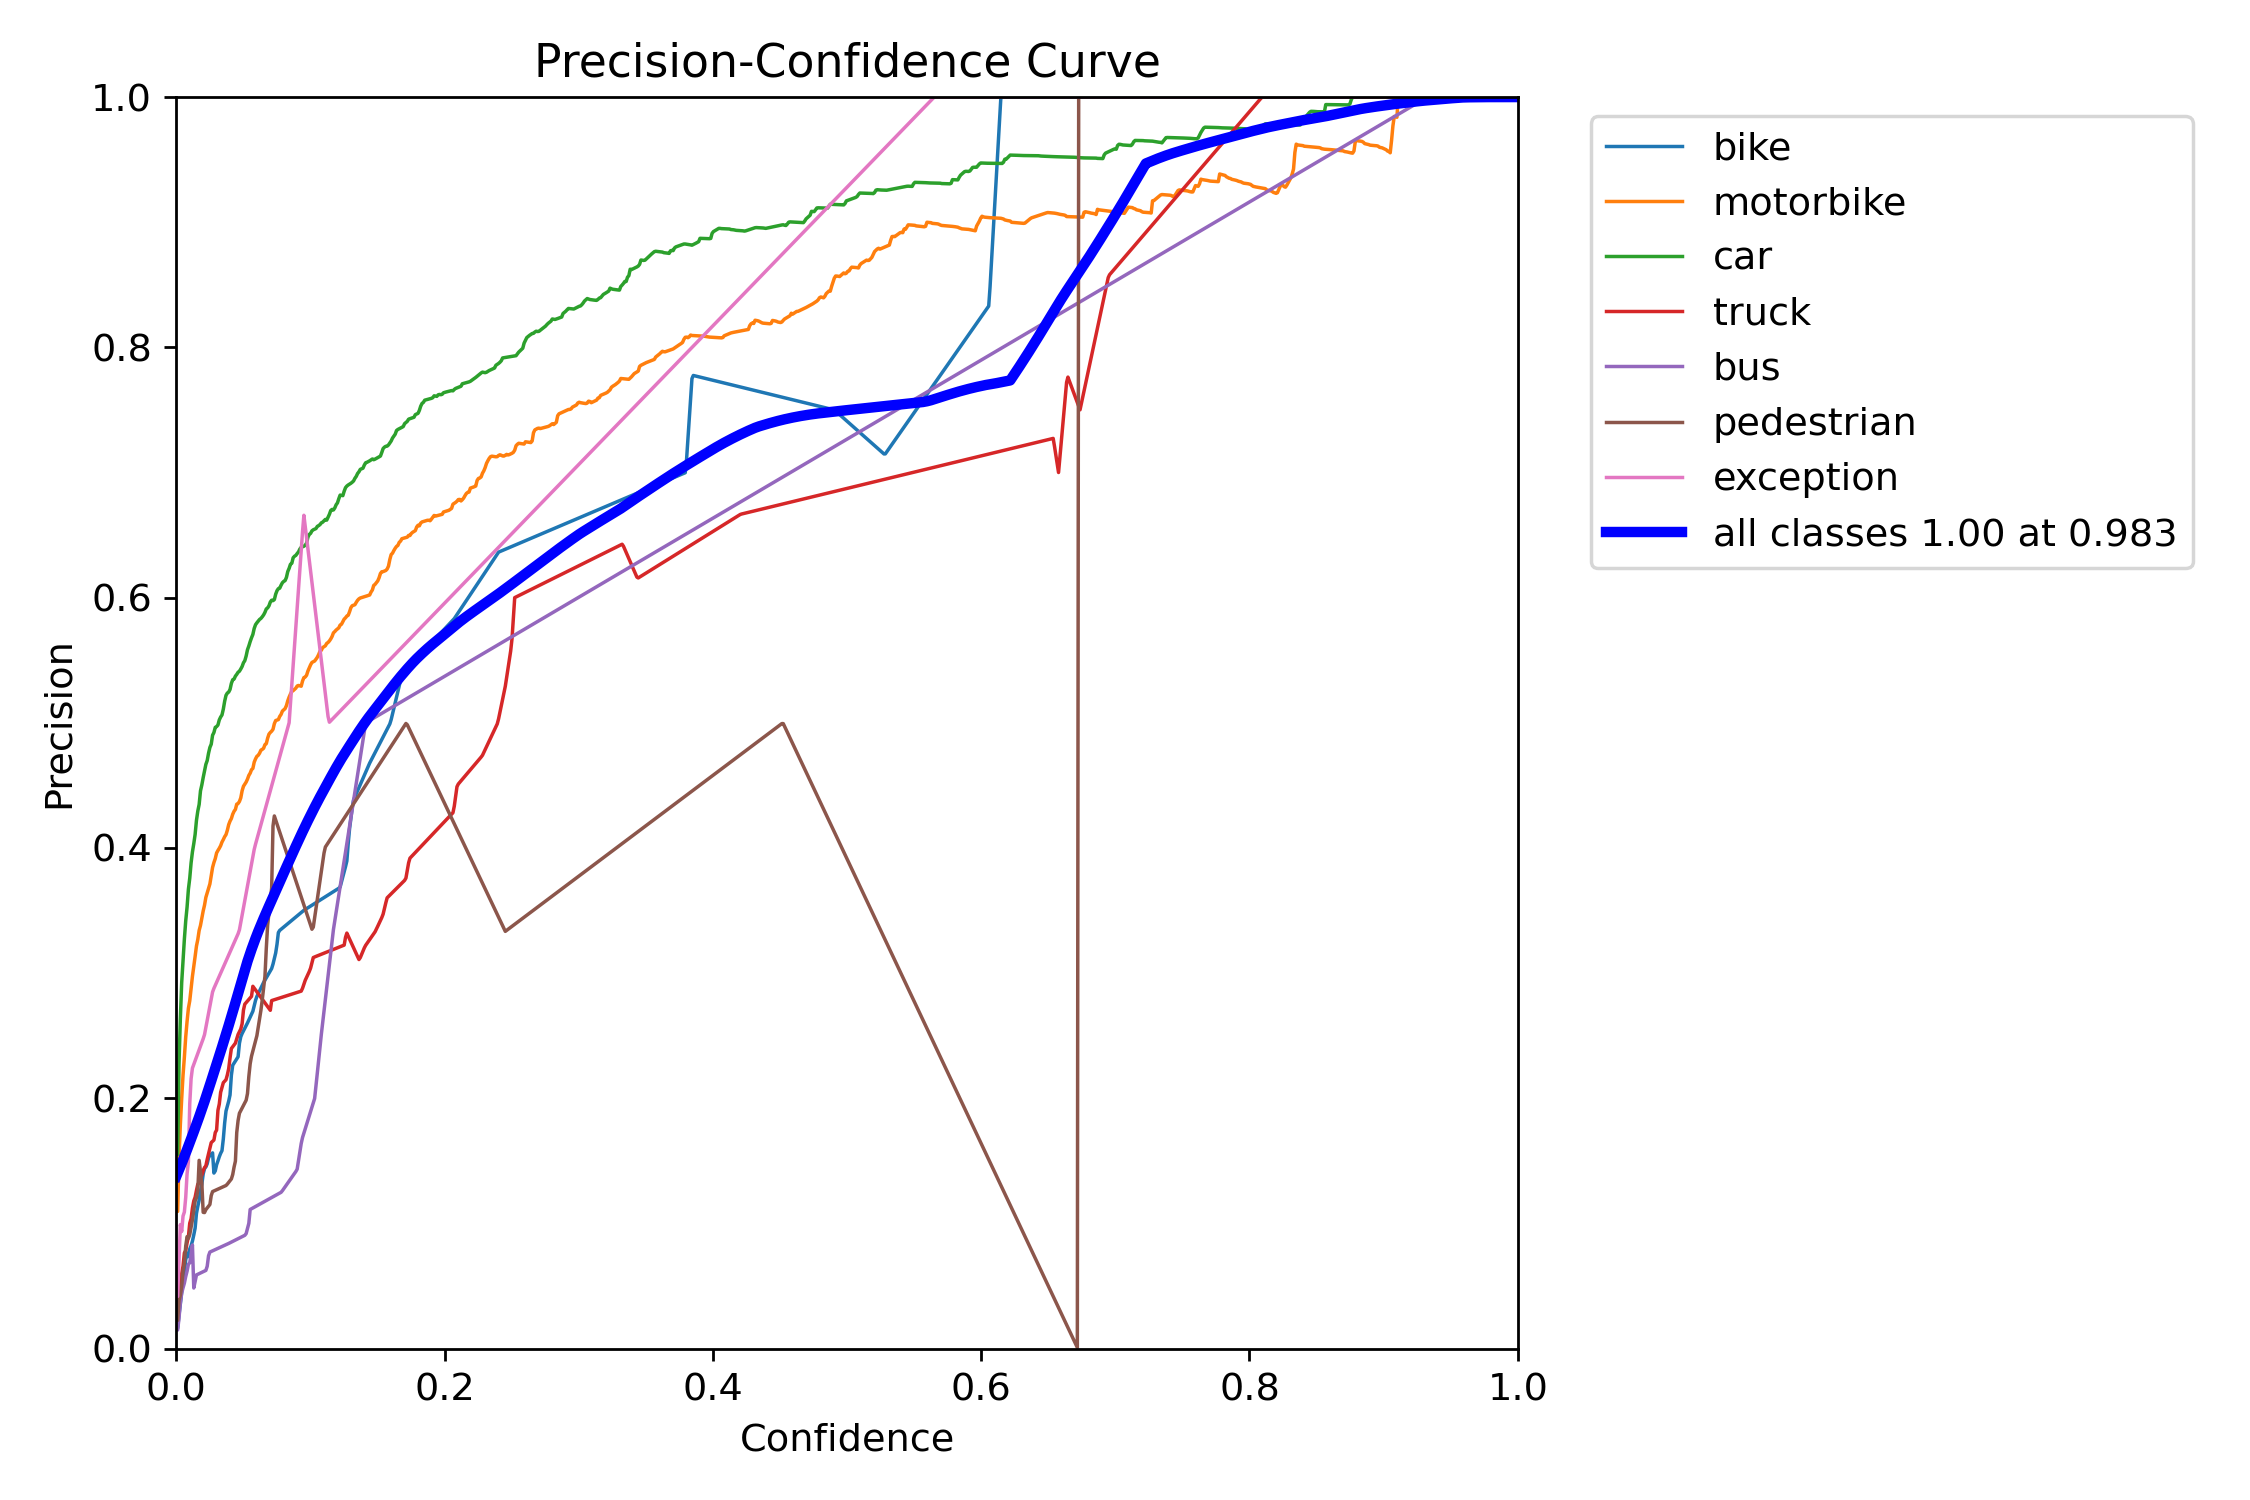

Displaying: BoxR_curve.png


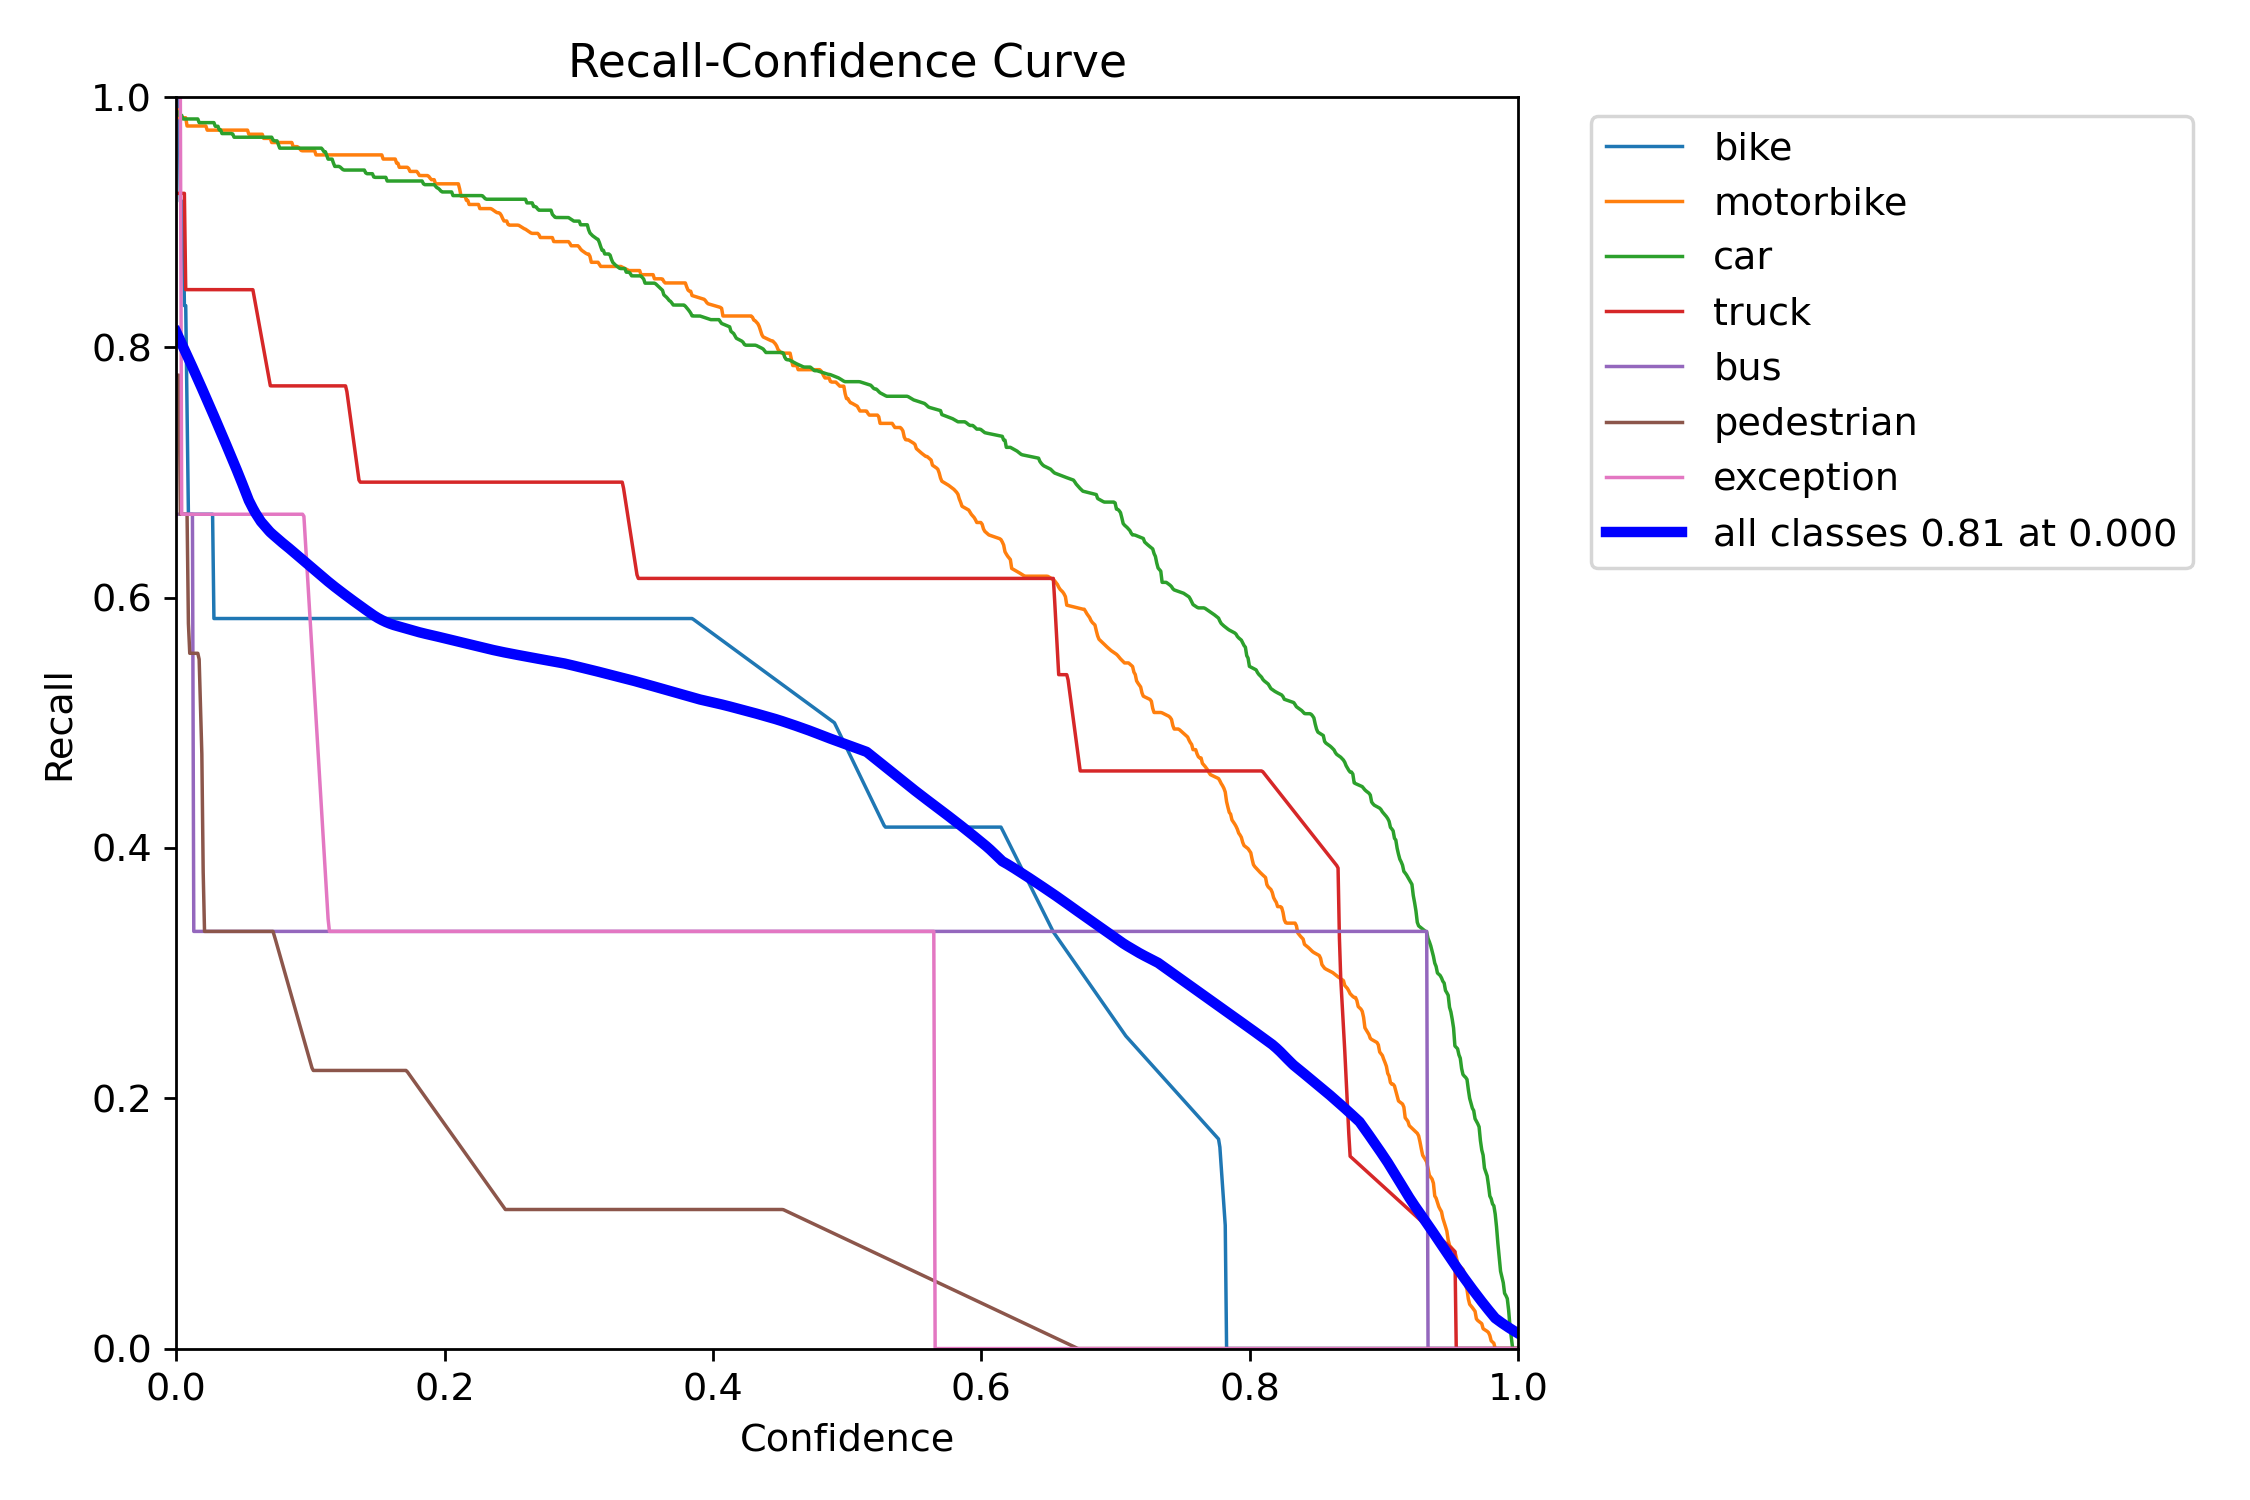

Displaying: confusion_matrix.png


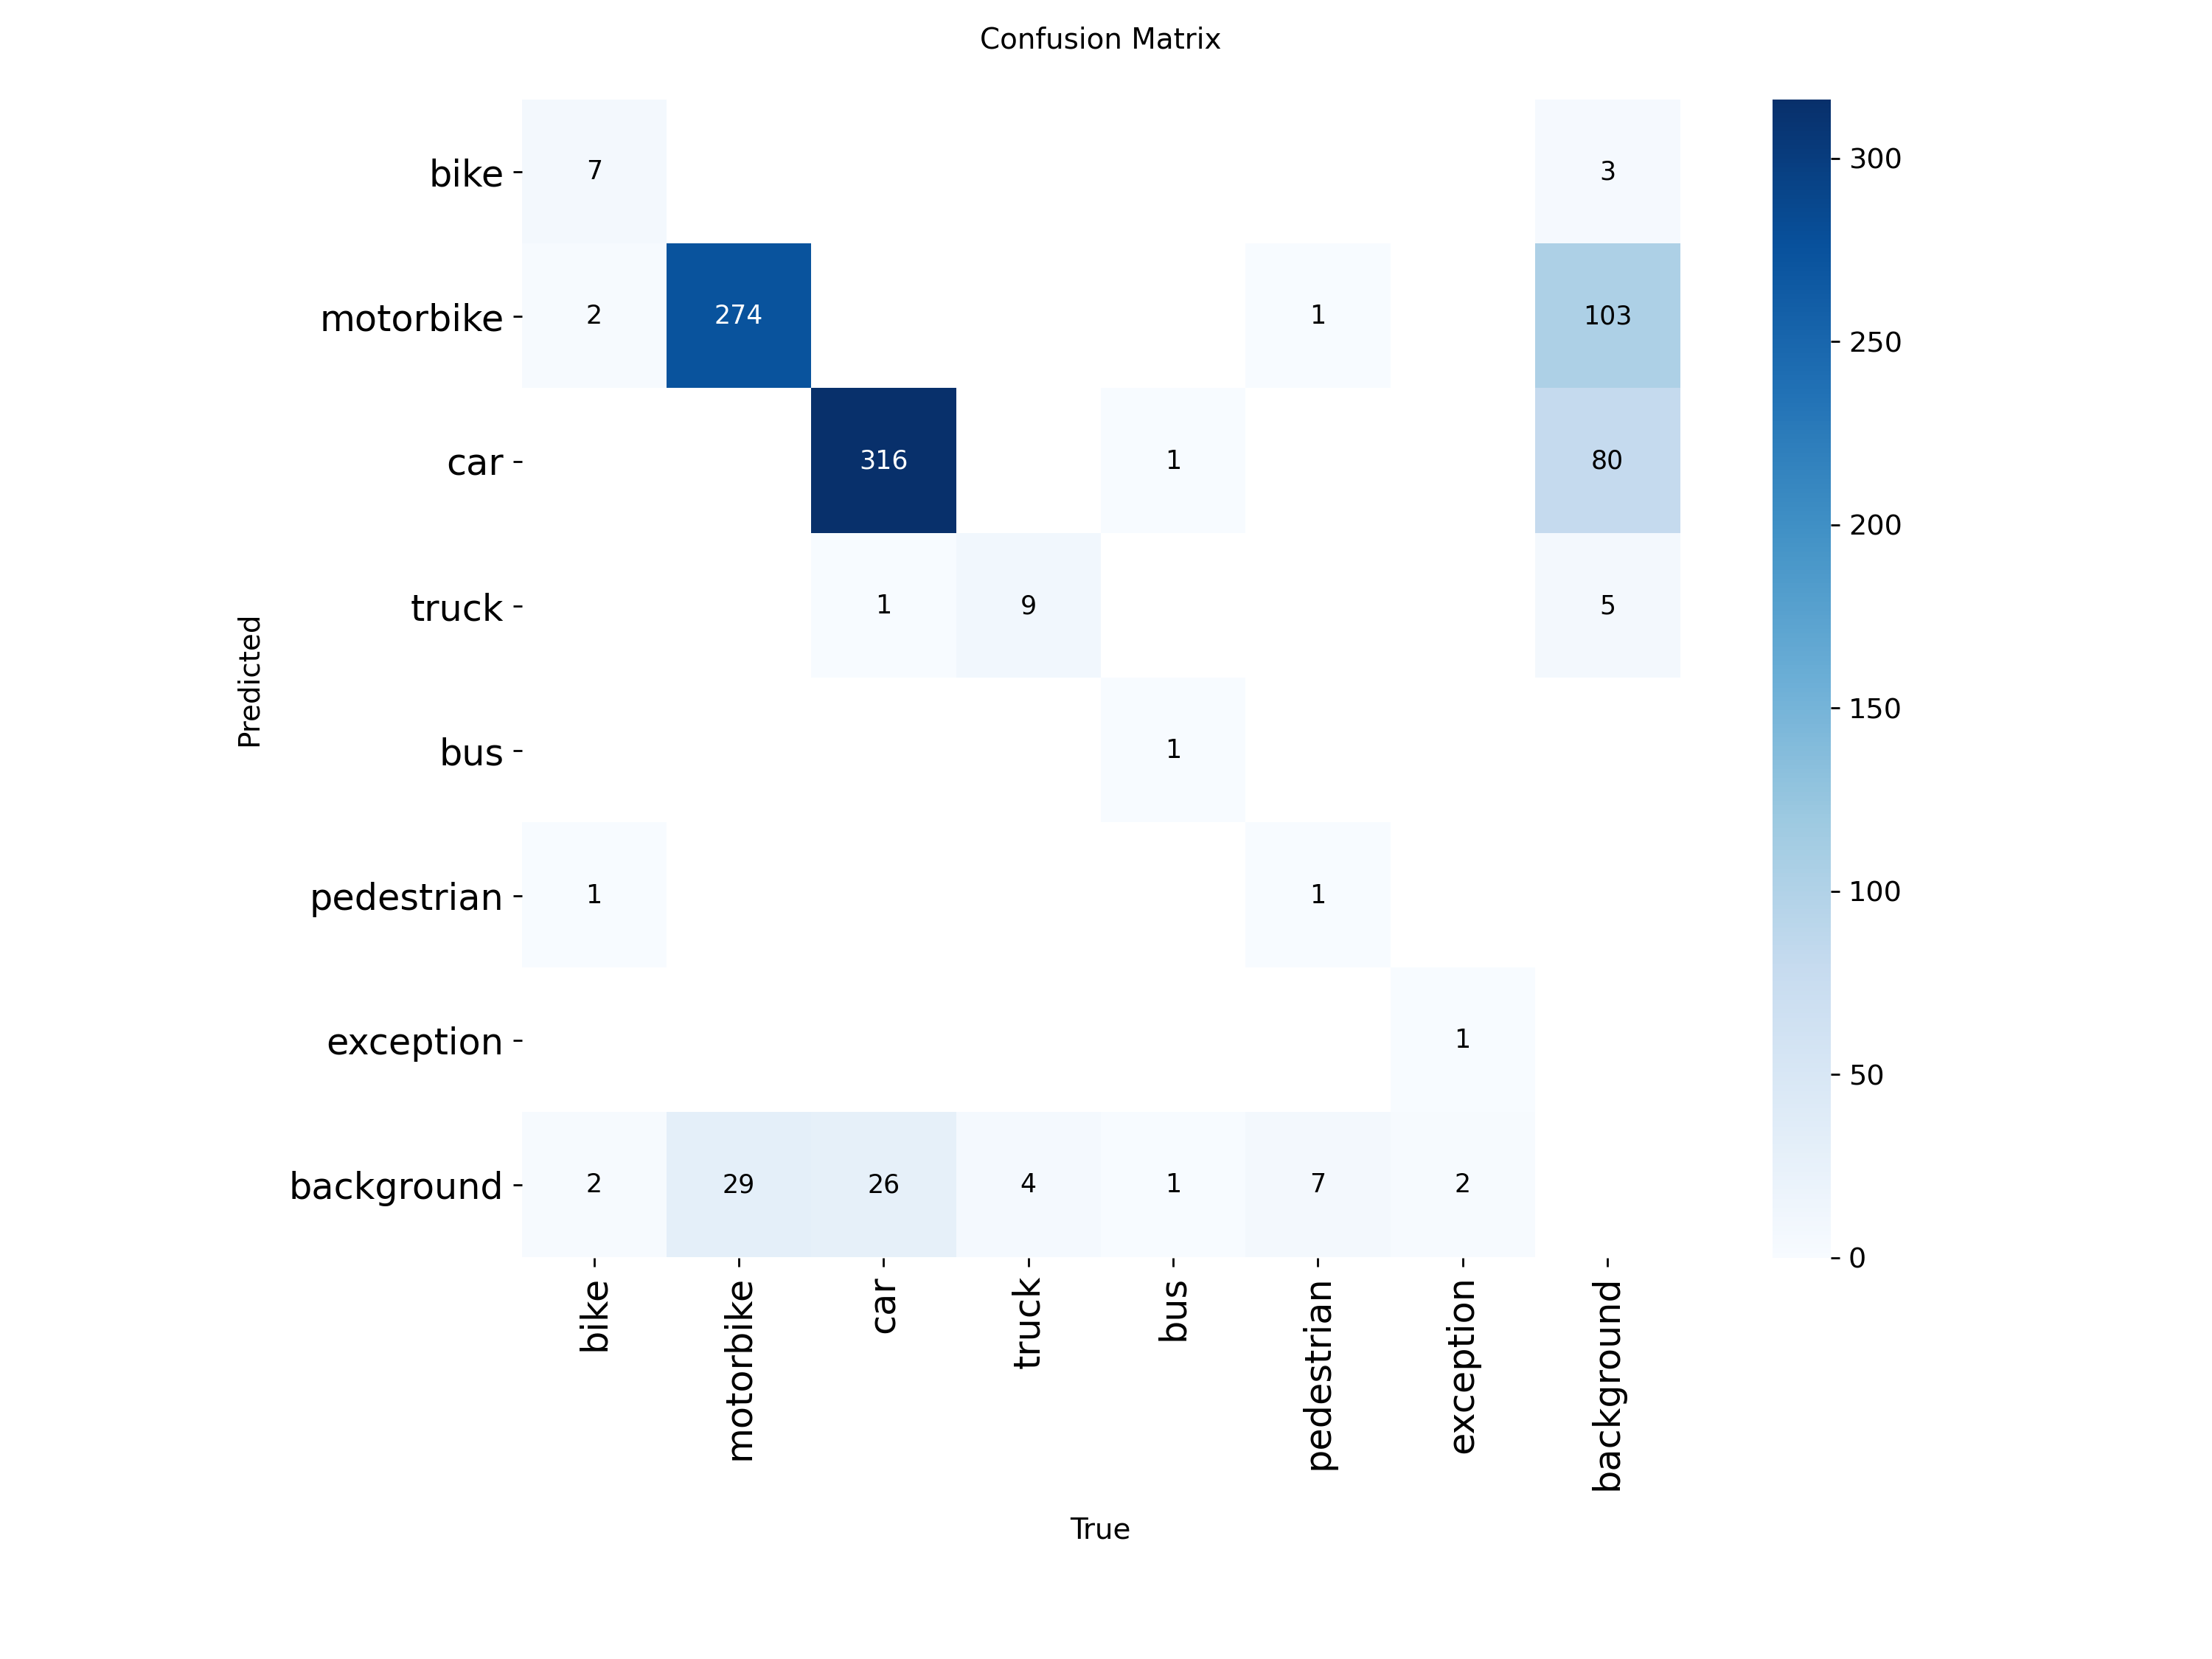

Displaying: confusion_matrix_normalized.png


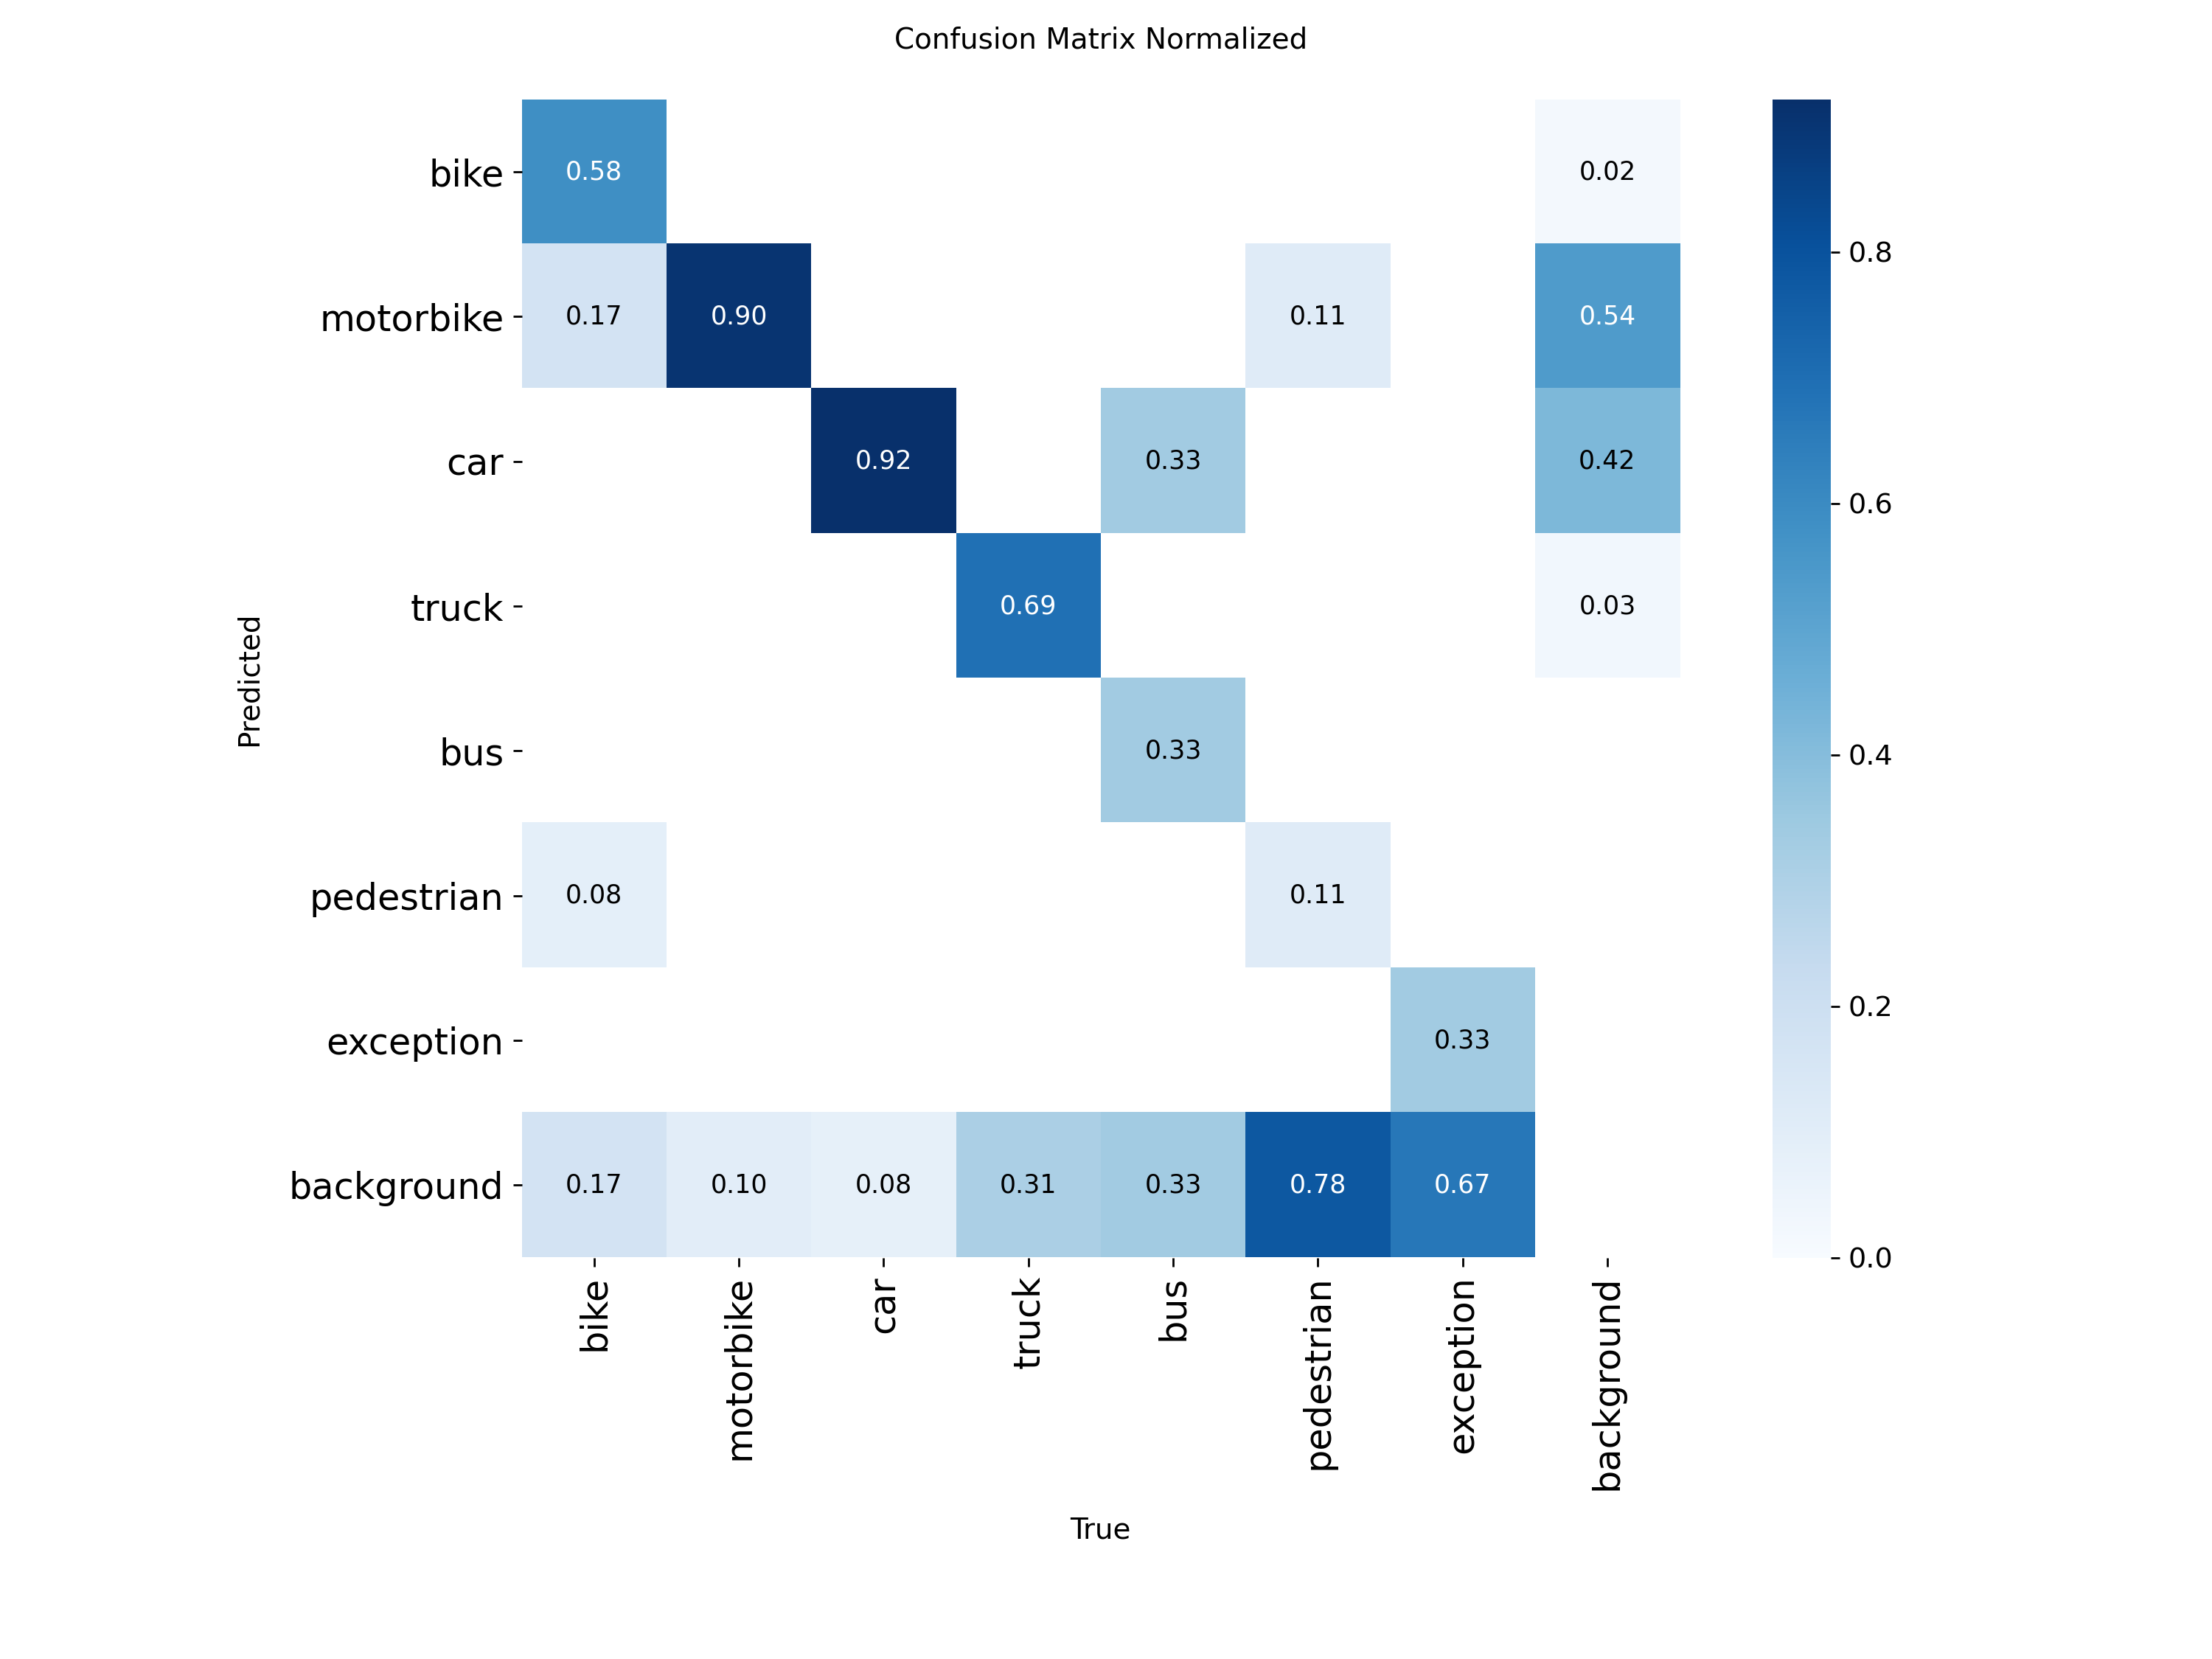

In [11]:
from IPython.display import Image, display
import glob
from pathlib import Path
import os

RUNS_DIR = Path('/content/drive/MyDrive/yolo26_vehicle_runs')

# The name argument for model.val was 'val_test_set'
results_dir = RUNS_DIR / "val_test_set"

print(f"Checking RUNS_DIR: {RUNS_DIR}")
if RUNS_DIR.exists():
    print(f"Contents of RUNS_DIR ({RUNS_DIR}):")
    for item in RUNS_DIR.iterdir():
        print(item)
else:
    print(f"RUNS_DIR not found: {RUNS_DIR}")
    print("This indicates a problem with the base path to your Google Drive runs. Please ensure your Google Drive is mounted correctly and the path is accurate.")

print(f"\nChecking specific results_dir: {results_dir}")
if results_dir.exists():
    print(f"Contents of {results_dir}:")
    for item in results_dir.iterdir():
        print(item)
else:
    print(f"Results directory not found: {results_dir}")
    print("This means the 'val_test_set' directory was not created or is inaccessible at this specific path.")

# Updated image filenames generated by model.val()
image_files = ['BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']

found_images = False
# Check directly in results_dir
if results_dir.exists(): # Only proceed if the directory exists
    for img_file in image_files:
        img_path = results_dir / img_file
        if img_path.exists():
            print(f"Displaying: {img_file}")
            display(Image(filename=str(img_path)))
            found_images = True

if not found_images and results_dir.exists():
    plots_dir = results_dir / 'plots'
    if plots_dir.exists():
        print(f"\nChecking in subdirectory: {plots_dir}")
        for img_file in image_files:
            img_path = plots_dir / img_file
            if img_path.exists():
                print(f"Displaying: {img_file}")
                display(Image(filename=str(img_path)))
                found_images = True

if not found_images:
    print("\nNone of the specified image files were found in the results directory or its 'plots' subdirectory.")